# Straight Waveguide -- Meep Baseline

A 2D FDTD (Meep) baseline for a straight silicon waveguide. Geometry is built once,
as a gdsfactory `Component`, and that same component drives both the Meep
simulation below and a real GDS layout export -- so the simulated device and the
exportable layout are never two different things.

1. **Component definition** -- global parameters.
2. **GDSFactory geometry** -- build the DUT as a gdsfactory `Component`.
3. **Geometry visualization** -- inspect the layout and permittivity map before
   paying for any FDTD run.
4. **2D Meep FDTD simulation** -- baseline run, field visualization, a length
   sweep, and S-parameter extraction (including a SAX-shaped `SDict`).
5. **SAX model fitting** -- fit an effective-index model from the length sweep via
   the **cutback method**, the same technique used to characterize waveguide loss
   on a real chip.

**Do not use "Run All."** Work through the notebook step by step, and stop at the
marked checkpoints to actually look at the plots before continuing.

## 1. Component definition -- Global Parameters

Every physical/simulation default shared across the toolkit's components lives in
one place, `pic_toolkit.params.GLOBAL_PARAMS`, rather than being redefined per
component (see `docs/simulation_settings_record.md` for the settings history).

**Governing relations.** A single-mode straight waveguide of effective index
$n_\mathrm{eff}(\lambda)$ propagates each mode with propagation constant
$$eta(\lambda) = rac{2\pi}{\lambda}\, n_\mathrm{eff}(\lambda),$$
so after a length $L$ the transmitted field acquires phase $eta L$ and, if the
mode also loses power to radiation/absorption at a rate $lpha$ (per unit length),
magnitude $e^{-lpha L/2}$ (power $T = |S_{21}|^2 = e^{-lpha L}$). Section 5's
cutback method exploits exactly this: $\ln T$ is linear in $L$, so a length
sweep's slope gives $lpha$ directly, independent of any single length's own
coupling/end-facet artifacts.

In [1]:
# pic_toolkit was installed with `pip install -e .` into the `mp` conda environment,
# so it imports directly -- no sys.path manipulation needed.
import inspect

import numpy as np
import matplotlib.pyplot as plt
import gdsfactory as gf

from pic_toolkit.params import GLOBAL_PARAMS
from pic_toolkit.meep_sim import waveguide
from pic_toolkit import checks, viz, sparams, design_points, sweep, style

style.apply_style()
%matplotlib inline

In [2]:
# GLOBAL_PARAMS (shared across every component) + this component's own extras
# (length_um, source/pml margins, cell_y_um) -- see pic_toolkit/params.py.
# derive_lengths() then fills in port_offset_um/source_offset_um/cell_x_um from
# length_um, so those three never drift out of sync when length_um is swept
# later (Section 4.2b).
params = waveguide.derive_lengths(dict(waveguide.DEFAULT_PARAMS))

print("Global Parameters (from pic_toolkit.params.GLOBAL_PARAMS)")
print(f"  waveguide width      : {params['wg_width_um']} um")
print(f"  core / clad index    : {params['core_index']} / {params['clad_index']}")
print(f"  polarization         : {params['polarization']}")
print(f"  wavelength band      : {params['wl_min_um']}-{params['wl_max_um']} um")
print(f"  resolution           : {params['resolution']} px/um")
print()
print("Component-specific parameters (meep_sim/waveguide.py's own DEFAULT_PARAMS)")
print(f"  characterized length : {params['length_um']} um  (port_offset_um = length_um / 2)")


Global Parameters (from pic_toolkit.params.GLOBAL_PARAMS)
  waveguide width      : 0.5 um
  core / clad index    : 2.7 / 1.44
  polarization         : TE
  wavelength band      : 1.3-1.4 um
  resolution           : 20 px/um

Component-specific parameters (meep_sim/waveguide.py's own DEFAULT_PARAMS)
  characterized length : 4.0 um  (port_offset_um = length_um / 2)


The values above are **imported**, not retyped -- editing `GLOBAL_PARAMS` in one file
changes what every component's baseline notebook prints and simulates. `length_um` is
not a global parameter (only `waveguide.py` has a "characterized length" in this
sense), so it stays in this module's own `DEFAULT_PARAMS`, itself built as
`{**GLOBAL_PARAMS, ...}`.

## 2. GDSFactory geometry

`build_gf_component(params)` builds the DUT -- exactly `length_um` of straight
waveguide -- as a gdsfactory `Component`, using `gf.components.straight()` on a
`gf.cross_section.strip()` of the global waveguide width. This is the same
`cross_section -> component` pattern `07_spiral_waveguide.ipynb` already uses for
`gf.components.spiral()`; here it's applied to the simplest possible component to
establish the pattern.

This component is centered on the origin (gdsfactory's own `straight()` spans
`x=[0, length]`, not `x=[-length/2, +length/2]`) so it drops into the port/cell
convention every other section below already uses, unchanged.

In [3]:
print(inspect.getsource(waveguide.build_gf_component))

def build_gf_component(params: dict):
    """The DUT itself: exactly length_um of straight waveguide -- what
    Sections 2-3 of notebooks/01_waveguide_baseline.ipynb display, and
    what would be exported to GDS for a real tapeout."""
    return _straight_centered(params["length_um"], params["wg_width_um"])



In [4]:
# Build the DUT (exactly length_um of straight waveguide) as a gdsfactory
# Component, then print its bounding box and port locations as a quick
# numeric sanity check before we render or simulate anything.
gf_component = waveguide.build_gf_component(params)
print(f"gdsfactory Component, bbox (um) = {gf_component.dbbox()}")
for p in gf_component.ports:
    print(f"  port {p.name}: center={tuple(p.dcenter)} um, width={p.dwidth} um")


gdsfactory Component, bbox (um) = (-2,-0.25;2,0.25)
  port o1: center=(-2.0, 0.0) um, width=0.5 um
  port o2: center=(2.0, 0.0) um, width=0.5 um


This is the same object that would be exported to GDS for a real tapeout
(`gf_component.write_gds(...)`) -- nothing about it is Meep-specific. Section 4 below
simulates it directly, rather than re-describing the same rectangle a second time in
Meep's own geometry primitives.

## 3. Geometry visualization

Two views, both cheap (no FDTD timestepping):

1. The raw gdsfactory layout (rendered via KLayout).
2. The Meep permittivity map derived from it (`gds_import.get_permittivity_map`, via
   `waveguide.get_permittivity_map(params)` -- Section 4.1 below), compared side by
   side against the **native** `build_geometry()` (`mp.Block`) permittivity map this
   toolkit used before this rewrite.

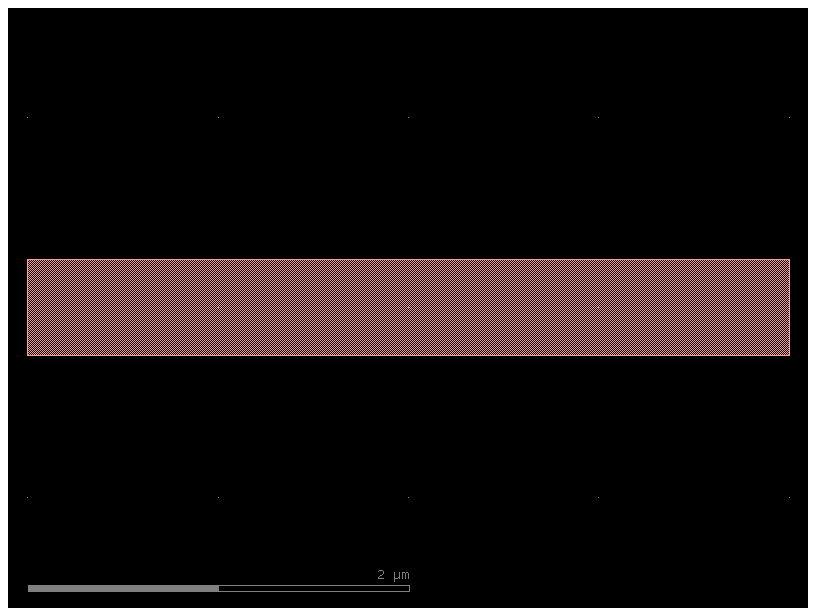

In [5]:
fig = gf_component.plot()
plt.show()

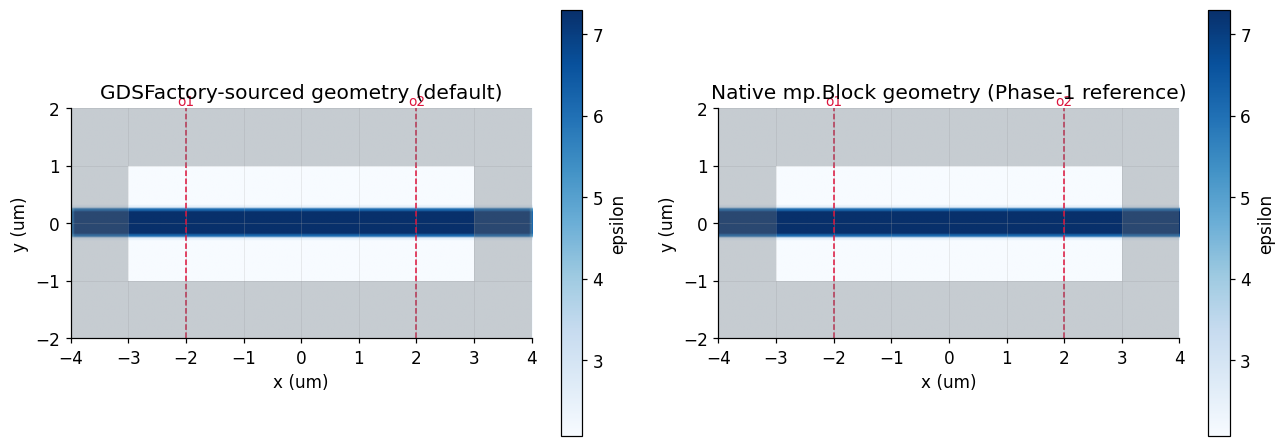

max |native - gds| eps difference INSIDE the characterized span:  0.000e+00
max |native - gds| eps difference OUTSIDE the characterized span: 1.142e+00  (expected -- see markdown below)


In [6]:
# Two independent geometry sources should agree everywhere it matters: the
# GDSFactory-derived permittivity map (what the rest of this notebook
# simulates) and the native mp.Block reference path (kept only for this
# comparison). get_permittivity_map() does NOT run any FDTD timestepping, so
# both maps are cheap to compute.
perm_map_gds = waveguide.get_permittivity_map(params, use_native_geometry=False)
perm_map_native = waveguide.get_permittivity_map(params, use_native_geometry=True)

ports = [
    (-params["port_offset_um"], 0, "o1", "v"),
    (params["port_offset_um"], 0, "o2", "v"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
viz.plot_permittivity(perm_map_gds.eps, perm_map_gds.extent_um, ax=axes[0], ports=ports, pml_um=params["dpml_um"])
axes[0].set_title("GDSFactory-sourced geometry (default)")
viz.plot_permittivity(perm_map_native.eps, perm_map_native.extent_um, ax=axes[1], ports=ports, pml_um=params["dpml_um"])
axes[1].set_title("Native mp.Block geometry (Phase-1 reference)")
fig.tight_layout()
plt.show()

# Compare the two eps arrays INSIDE the characterized span (should match to
# floating-point noise) vs. OUTSIDE it (expected to differ -- see markdown below).
nx, _ = perm_map_native.eps.shape
xs = np.linspace(*perm_map_native.extent_um[:2], nx)
inside = np.abs(xs) < params["port_offset_um"] - 0.05
outside = ~inside
print(f"max |native - gds| eps difference INSIDE the characterized span:  "
      f"{np.abs(perm_map_native.eps[inside] - perm_map_gds.eps[inside]).max():.3e}")
print(f"max |native - gds| eps difference OUTSIDE the characterized span: "
      f"{np.abs(perm_map_native.eps[outside] - perm_map_gds.eps[outside]).max():.3e}  "
      f"(expected -- see markdown below)")


**Inside the two ports, the two geometries are pixel-identical** (difference is
exactly floating-point noise) -- the gdsfactory-sourced geometry is not a
reinterpretation of the native one, it produces the same waveguide. Outside the
ports they genuinely differ, and that difference is expected, not a bug: the native
`build_geometry()` is a Phase-1 idealization of an **infinite** waveguide (an
`mp.inf`-sized block spanning the whole cell), while the gdsfactory-sourced geometry
models a **finite** device of the stated `length_um`, extended only as far as the
simulation's source planes need (standard FDTD input/output access-waveguide stubs --
see `build_geometry_from_gds`'s docstring). A real chip's waveguide is finite too, so
this is the more physically honest of the two models.

> **STOP -- inspect both permittivity maps before running any FDTD.**
>
> Check: is the core (dark blue strip) centered, the right width, and fully
> surrounded by cladding in both panels? Do the two panels agree with each other
> between the two dashed port lines? Is there visible PML clearance (shaded gray
> band) beyond the ports on every side?

## 4. 2D Meep FDTD simulation

### 4.1-4.2 Baseline run (single length)

`simulate_baseline()` now defaults to the gdsfactory-sourced geometry
(`use_native_geometry=False`) -- the permittivity map above, at `length_um=4.0`, is
exactly what gets simulated below. As in the original notebook, this runs the full
two-port characterization **twice** (exciting `o1`, then `o2`) to measure the full
2x2 S-matrix from genuinely independent data.

In [7]:
# Full two-port characterization: excites port o1, then o2, independently,
# and measures the complete 2x2 S-matrix from genuinely separate FDTD runs.
result = waveguide.simulate_baseline(params)
print(f"{len(result.wavelengths_um)} wavelength points, "
      f"{result.wavelengths_um.min():.4f}-{result.wavelengths_um.max():.4f} um")


21 wavelength points, 1.3017-1.4020 um


### 4.3 Electromagnetic field visualization -- polarization convention

This waveguide is simulated in the TE polarization (Section 1). In Meep's 2D
convention, TE's dominant out-of-plane field component is `Hz`, not `Ez` -- both
are captured below and whichever actually dominates is reported, so the result
is confirmed by direct measurement rather than assumed.

dominant field component = Hz


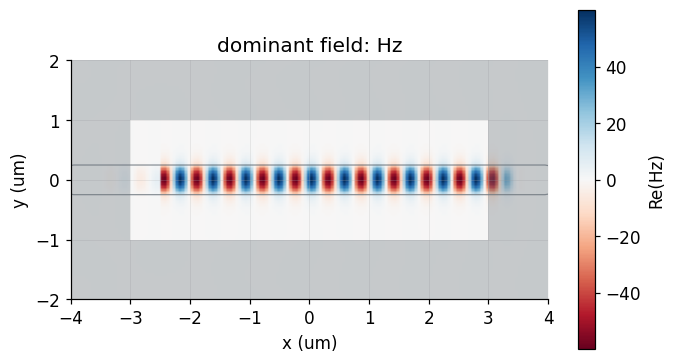

In [8]:
# Plot whichever field component (Ez or Hz) actually dominates -- see the
# markdown above for why this is measured, not assumed.
fs = result.field_snapshot
fig, ax = plt.subplots(figsize=(7, 4))
viz.plot_field(fs.field, fs.eps, fs.extent_um, component=fs.component, ax=ax, pml_um=params["dpml_um"])
ax.set_title(f"dominant field: {fs.component}")
print(f"dominant field component = {fs.component}")
plt.show()


> **STOP -- inspect the electromagnetic field before continuing.**
>
> Check: is the mode confined to the core, with a clean, regular propagation pattern
> and no visible standing waves or leakage into the cladding?

### 4.4 S-parameters: baseline extraction and SAX-shaped export

Same complete complex 2x2 S-matrix as the original notebook, plus a new conversion
into SAX's `SDict` convention (`{(port_in, port_out): array}`), via the new
`sparams.to_sdict()` helper -- de-duplicating the tuple-key construction every
`models/*.py` file used to build inline.

S11: |S|^2=0.0003  phase=-3.140 rad  (at wavelength=1.3500 um)
S12: |S|^2=1.0000  phase=1.700 rad  (at wavelength=1.3500 um)
S21: |S|^2=1.0000  phase=1.700 rad  (at wavelength=1.3500 um)
S22: |S|^2=0.0003  phase=-3.139 rad  (at wavelength=1.3500 um)


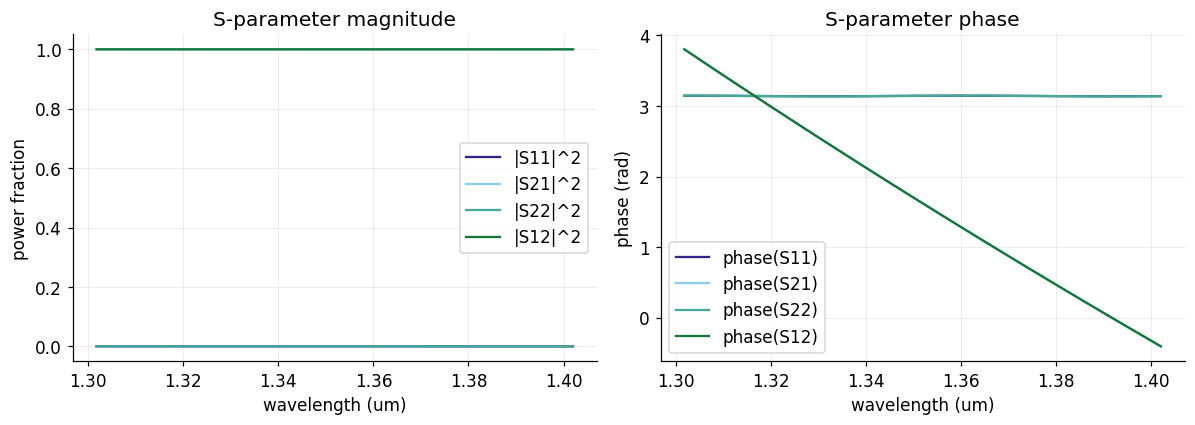

In [9]:
# Print the complex S-matrix at the band-center wavelength, then plot the
# full magnitude+phase spectrum for all four S-parameters (not just S21) --
# viz.plot_sparams applies this toolkit's shared color/style convention.
for key in ["11", "12", "21", "22"]:
    s = result.s_matrix[key]
    i_mid = len(s) // 2
    print(f"S{key}: |S|^2={np.abs(s[i_mid])**2:.4f}  phase={np.angle(s[i_mid]):.3f} rad  "
          f"(at wavelength={result.wavelengths_um[i_mid]:.4f} um)")

fig = viz.plot_sparams(result.wavelengths_um, result.s_matrix, pairs=("11", "21", "22", "12"))
plt.show()


In [10]:
# Convert this notebook's own {"11": arr, ...} S-matrix convention into the
# SAX-native SDict format ({(port_in, port_out): array}) that models/*.py uses.
sdict = sparams.to_sdict(result.s_matrix, result.port_names)
print("SAX SDict keys:", list(sdict.keys()))
print("(o1, o2) shape:", sdict[("o1", "o2")].shape, " dtype:", sdict[("o1", "o2")].dtype)


SAX SDict keys: [('o1', 'o1'), ('o1', 'o2'), ('o2', 'o1'), ('o2', 'o2')]
(o1, o2) shape: (21,)  dtype: complex128


### 4.2b Length sweep (for Section 5's cutback fit)

**The baseline above has been inspected and validated -- only now do we sweep.**
`sweep.grid_sweep()` -- the same generic sweep driver every other component's sweep
uses -- varies `length_um` from **10.0 to 11.0 um in 0.1 um steps**. Each point is a
genuinely different, independently-built gdsfactory `Component`, not a
reinterpretation of one simulation.

`S21`'s phase accumulates as `2*pi*n_eff*L/lambda`, so plotting `S21` against `L` at
a fixed wavelength traces out a point per length along a circle in the complex
plane -- its real part is a clean sine curve, which is exactly Section 5's fit
target.

In [11]:
# Sweep length_um 10.0-11.0um in 0.1um steps -- sweep.grid_sweep runs
# simulate_baseline() once per length, saving one artifact (npz+json) per
# point, and returns a manifest row per point recording whether it passed
# the standard sanity checks.
LENGTH_SWEEP_UM = [round(float(x), 2) for x in np.arange(10.0, 11.01, 0.1)]
print("sweeping length_um over:", LENGTH_SWEEP_UM)

length_rows = sweep.grid_sweep(
    simulate_fn=waveguide.simulate_baseline,
    base_params=params,
    param_grid={"length_um": LENGTH_SWEEP_UM},
    artifact_dir="../data/sparams/waveguide/sweep",
    component_name="waveguide",
)
n_passed = sum(row["validation_passed"] for row in length_rows)
print(f"length sweep: {n_passed}/{len(length_rows)} points passed validation")

manifest_path = "../data/sparams/waveguide/sweep/manifest.csv"
sweep.save_manifest(length_rows, manifest_path)
print(f"Saved manifest to {manifest_path}")


sweeping length_um over: [10.0, 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11.0]
[1/11  9%] running waveguide (length_um=10.0) ...


[2/11  18%] running waveguide (length_um=10.1) ...


[3/11  27%] running waveguide (length_um=10.2) ...


[4/11  36%] running waveguide (length_um=10.3) ...


[5/11  45%] running waveguide (length_um=10.4) ...


...

[8/11  72%] running waveguide (length_um=10.7) ...


[9/11  81%] running waveguide (length_um=10.8) ...


[10/11  90%] running waveguide (length_um=10.9) ...


[11/11  100%] running waveguide (length_um=11.0) ...


length sweep: 11/11 points passed validation
Saved manifest to ../data/sparams/waveguide/sweep/manifest.csv


Fitting at wavelength = 1.3500 um


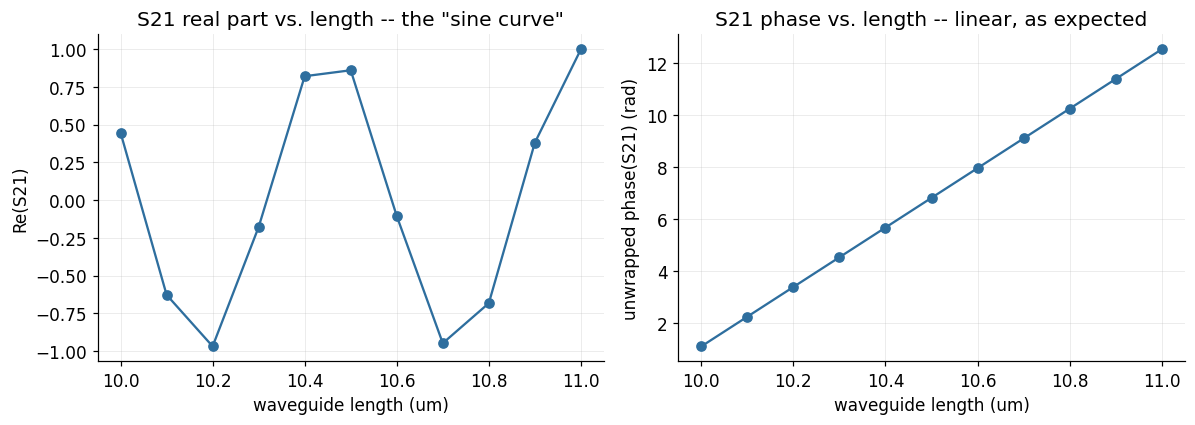

In [12]:
# Read S21 back out of each swept-length artifact, at the same band-center
# wavelength used elsewhere in this notebook, so every point is compared at
# exactly one wavelength as length varies.
i_mid = len(result.wavelengths_um) // 2
wl0 = float(result.wavelengths_um[i_mid])  # representative (band-center) wavelength for the fit
print(f"Fitting at wavelength = {wl0:.4f} um")

s21_by_length = []
for L in LENGTH_SWEEP_UM:
    a = sparams.load_artifact(f"../data/sparams/waveguide/sweep/waveguide_length{L}")
    s21_by_length.append(a.s_matrix["21"][i_mid])
s21_by_length = np.array(s21_by_length)
lengths_um = np.array(LENGTH_SWEEP_UM)

# unwrap() removes the artificial 2*pi jumps atan2 introduces, so the
# accumulated phase reads as a straight line vs. length instead of a sawtooth.
phase_unwrapped = np.unwrap(np.angle(s21_by_length))

fig, (ax_re, ax_ph) = plt.subplots(1, 2, figsize=(11, 4))
ax_re.plot(lengths_um, s21_by_length.real, "o-", color=style.COLOR_STEEL)
ax_re.set_xlabel("waveguide length (um)")
ax_re.set_ylabel("Re(S21)")
ax_re.set_title("S21 real part vs. length -- the \"sine curve\"")
ax_ph.plot(lengths_um, phase_unwrapped, "o-", color=style.COLOR_STEEL)
ax_ph.set_xlabel("waveguide length (um)")
ax_ph.set_ylabel("unwrapped phase(S21) (rad)")
ax_ph.set_title("S21 phase vs. length -- linear, as expected")
fig.tight_layout()
plt.show()


As predicted: `Re(S21)` traces a clean sine curve as the accumulated phase
`2*pi*n_eff*L/lambda` sweeps through multiple cycles over the 1um length sweep
(period `lambda/n_eff ~ 0.6um`, short compared to the swept range), while the
unwrapped phase itself increases linearly with length -- exactly the relationship
Section 5 fits to extract `n_eff`.

## 5. SAX model fitting -- the cutback method

`models/waveguide.py` used to only interpolate the raw FDTD S21 lookup table at one
fixed, hardcoded length -- it couldn't answer "what if the waveguide is a different
length", which any real circuit composition (e.g. an MZI's two unequal arms) needs.

Instead, this section fits an **analytic** effective-index model using the
**cutback method** -- the same technique used to measure real fabricated waveguide
loss on a chip: simulate several different lengths of the same waveguide and look
at how the signal changes with length, rather than extracting a property from a
single length alone.

`unwrap(angle(S21))` vs. `L` is linear with slope `2*pi*n_eff/lambda` -> fit for
`n_eff`. (This lossless 2D model has no absorption mechanism, so a companion
amplitude/loss fit here would just be fitting FDTD's own discretization noise --
see `docs/simulation_settings_record.md` -- so this notebook fits phase only.)

Fitted n_eff : 2.4538


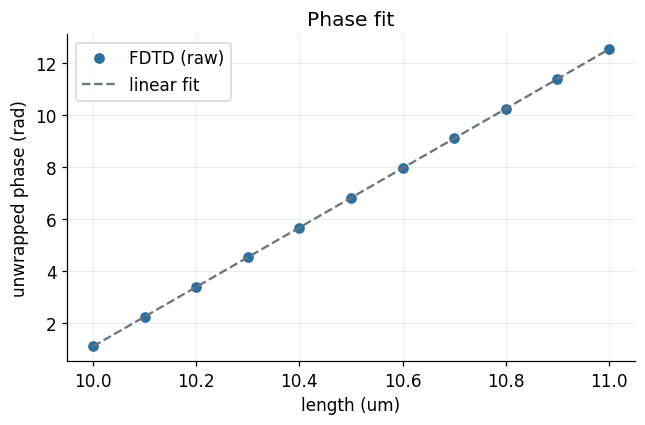

max |phase residual| : 1.38e-06 rad


In [13]:
# Linear fit: unwrapped phase vs. length has slope 2*pi*n_eff/lambda, so
# solving for n_eff is a one-line inversion of that slope.
phase_fit = np.polyfit(lengths_um, phase_unwrapped, 1)
n_eff_fit = phase_fit[0] * wl0 / (2 * np.pi)
print(f"Fitted n_eff : {n_eff_fit:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lengths_um, phase_unwrapped, "o", color=style.COLOR_STEEL, label="FDTD (raw)")
ax.plot(lengths_um, np.polyval(phase_fit, lengths_um), "--", color=style.COLOR_REFERENCE, label="linear fit")
ax.set_xlabel("length (um)"); ax.set_ylabel("unwrapped phase (rad)")
ax.set_title("Phase fit"); ax.legend()
fig.tight_layout()
plt.show()

# How far the raw FDTD points deviate from a perfectly straight line -- see
# the STOP checkpoint below for what a "good" value here looks like.
phase_residual = phase_unwrapped - np.polyval(phase_fit, lengths_um)
print(f"max |phase residual| : {np.max(np.abs(phase_residual)):.2e} rad")


This is a lossless 2D effective-index model (no material conductivity, no
radiation channel for a straight waveguide), so `n_eff` is the only physically
meaningful quantity to fit here. A real propagation-loss number would require a
lossy material model (e.g. `racetrack.py`'s `ring_conductivity`/`D_conductivity`
trick) or a full 3D simulation -- see `docs/simulation_settings_record.md`.

> **STOP -- inspect the fit residual before saving.**
>
> The phase residual should sit at the `1e-6` rad level with no visible structure
> vs. length -- a resonance-free straight waveguide's phase really is linear in
> length, so a poor fit here would mean something is wrong with the sweep, not the
> fitting method.

## 6. Sanity checks

Same checks as the original notebook, run against the Section 4.2 **baseline**
(single-length) result -- energy conservation and reciprocity, from two genuinely
independent excitation runs.

In [14]:
# Run the shared 3-check validator (energy conservation, reciprocity,
# passivity) against the Section 4.2 baseline result, and hard-stop (assert)
# rather than continuing with a result that hasn't been shown to be physical.
validation = checks.run_all_checks(result.s_matrix)
import json
print(json.dumps(validation, indent=2))
assert validation["passed"], "Baseline failed sanity checks -- do not save or use this result."
print("\nBaseline validated.")


{
  "energy_conservation": {
    "max_deviation_port1": 0.0004004636860726052,
    "max_deviation_port2": 0.00040022985383325604,
    "max_deviation": 0.0004004636860726052,
    "max_loss_fraction_allowed": 0.0,
    "tolerance": 0.01,
    "passed": true
  },
  "reciprocity": {
    "max_diff_s12_s21": 5.429830699550995e-06,
    "max_diff_s11_s22": 3.264069561651544e-05,
    "max_diff": 3.264069561651544e-05,
    "tolerance": 0.01,
    "passed": true
  },
  "passivity": {
    "max_magnitude": 1.0000045347114301,
    "tolerance": 0.01,
    "passed": true
  },
  "passed": true
}

Baseline validated.


## 7. Save artifact and design point

Same `.npz`+`.json` artifact format as before. The design point gains one new key,
`fitted_model` -- the cutback-fit coefficients from Section 5 -- alongside the
existing raw-artifact reference, so both the validated raw FDTD data and the fitted
analytic model are recoverable from this one file.

In [15]:
# Bundle geometry/material/simulation parameters + the validation result into
# one metadata dict, then save the raw S-parameters alongside it as a
# .npz (arrays) + .json (metadata) artifact pair -- the same format every
# other component in this toolkit uses.
artifact_stem = "../data/sparams/waveguide/baseline/waveguide_baseline"

metadata = {
    "component": "waveguide",
    "geometry_params": {
        "wg_width_um": result.sim_params["wg_width_um"],
        "length_um": result.sim_params["length_um"],
    },
    "material_params": {
        "core_index": result.sim_params["core_index"],
        "clad_index": result.sim_params["clad_index"],
    },
    "polarization": f"TE ({result.field_snapshot.component} out-of-plane, confirmed dominant -- see Section 4.3)",
    "geometry_source": "gdsfactory (build_gf_component -> build_geometry_from_gds)",
    "meep_resolution": result.sim_params["resolution"],
    "simulation_params": {
        k: result.sim_params[k]
        for k in ["wl_min_um", "wl_max_um", "n_freq", "dpml_um", "cell_x_um",
                  "cell_y_um", "port_offset_um", "source_offset_um"]
    },
    "meep_version": result.sim_params["meep_version"],
    "python_version": result.sim_params["python_version"],
    "creation_date": result.sim_params["creation_date"],
    "validation": validation,
}

sparams.save_artifact(
    artifact_stem, result.wavelengths_um, result.freqs,
    result.s_matrix, result.port_names, metadata,
)
print(f"Saved artifact: {artifact_stem}.npz / .json")


Saved artifact: ../data/sparams/waveguide/baseline/waveguide_baseline.npz / .json


In [16]:
# The design point is the single source of truth for this component's
# selected parameters AND its fitted analytic model -- anything downstream
# (models/waveguide.py, circuit-level SAX composition) reads from this one
# YAML file, never from the notebook directly.
design_point_path = "../data/design_points/waveguide.yaml"

design_points.save_design_point(design_point_path, {
    "component": "waveguide",
    "parameters": {**metadata["geometry_params"], **metadata["material_params"]},
    "source_artifact": "data/sparams/waveguide/baseline/waveguide_baseline",
    "fitted_model": {
        "n_eff": float(n_eff_fit),
        "lambda_um": float(wl0),
        "fit_method": "length-sweep cutback (phase slope vs L; lossless model, see "
                       "docs/simulation_settings_record.md)",
        "length_sweep_um": LENGTH_SWEEP_UM,
    },
    "provenance": {
        "method": "baseline_plus_length_sweep_cutback_fit",
        "date": metadata["creation_date"],
        "meep_version": metadata["meep_version"],
    },
    "validation": validation,
    "rationale": (
        "Baseline geometry/S-parameters validated at length_um=4.0 (Sections 4.1-4.2, 6). "
        "n_eff fit via the cutback method against an independent length_um=10.0-11.0um "
        "sweep (Section 4.2b/5), so the resulting analytic model generalizes to arbitrary "
        "waveguide lengths for circuit-level (SAX) composition."
    ),
})
print(f"Saved design point: {design_point_path}")


Saved design point: ../data/design_points/waveguide.yaml


## 8. The waveguide SAX model

`src/pic_toolkit/models/waveguide.py` is the reusable LEGO brick built from the
design point saved above. **It is not exercised in this notebook** -- this notebook
already imports meep, and the whole point of the SAX model is that it must work in a
process that never has -- so it should be verified separately, in a clean, meep-free
process (the same approach every other component uses).

In [17]:
with open("../src/pic_toolkit/models/waveguide.py") as f:
    print(f.read())

"""SAX-compatible component model for the straight waveguide.

Architectural rule: this file NEVER imports meep, and NEVER launches an FDTD
simulation. It only reads the cached, validated `fitted_model` coefficients
(n_eff, propagation loss) that the Meep baseline notebook already fit via the
length-sweep cutback method, via the design point that stores them. If that
design point doesn't exist yet, loading it below raises a clear error telling
the user to run the baseline notebook first.

Evaluating an analytic model (rather than interpolating the raw FDTD S21
lookup table the earlier version of this file used) is what makes `length_um`
a free argument here: a fixed-length lookup table can't answer "what if the
waveguide is a different length", which every real circuit composition (e.g.
an MZI's two arms) needs.
"""

from __future__ import annotations

from pathlib import Path

import numpy as np

from .. import design_points, sparams

_REPO_ROOT = Path(__file__).resolve().parents[3]
_

---

## 9. Summary

Same validated straight-waveguide baseline as before, now built from a single
gdsfactory `Component` shared by the GDS layout and the Meep simulation, plus an
analytic `n_eff`/propagation-loss model fit via a length-sweep cutback measurement --
generalizing to any waveguide length, not just the one simulated here. Continue to
`02_bent_waveguide.ipynb` for the next "LEGO block".